# Klasifikasi Motif Batik Megamendung dan Parang (Baseline Tanpa Preprocessing)

Notebook ini merupakan pembanding (baseline) dari eksperimen utama. Citra hanya dikonversi ke grayscale sebagai syarat teknis perhitungan GLCM, tanpa ekualisasi histogram, normalisasi, median filter, sharpening, morfologi, maupun threshold. Hasil dari notebook ini digunakan untuk menilai seberapa besar kontribusi tahap preprocessing manual terhadap akurasi klasifikasi.

## Import Library

Mengimpor seluruh library yang dibutuhkan: OpenCV untuk operasi citra, NumPy dan Pandas untuk manipulasi data, scikit-image untuk ekstraksi GLCM, serta scikit-learn untuk pembagian data dan model klasifikasi (SVM, KNN, Random Forest).

In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns


## Data Loading

Struktur folder dataset yang diharapkan:
```
.
└── Assets
    ├── megamendung
    │   ├── image1.jpg
    │   └── ...
    └── parang
        ├── image1.jpg
        └── ...
```

Membaca seluruh citra dari folder `Assets/`, mengubah ukurannya menjadi 224x224 piksel, lalu menghitung jumlah data per kelas secara manual untuk memastikan distribusi Megamendung dan Parang seimbang.

In [2]:
data = []
labels = []
file_name = []

for sub_folder in os.listdir("Assets/"):
    sub_folder_files = os.listdir(os.path.join("Assets/", sub_folder))
    for filename in sub_folder_files:
        img_path = os.path.join("Assets/", sub_folder, filename)
        img = cv.imread(img_path)
        img = img.astype(np.uint8)
        img = cv.resize(img, (224, 224))
        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

data = np.array(data)
labels = np.array(labels)

print("Total data:", len(data))

# Hitung distribusi manual
kelas = []
counts = []
for label in labels:
    if label not in kelas:
        kelas.append(label)
        counts.append(0)
    idx = kelas.index(label)
    counts[idx] += 1

print("Label unik:", kelas)
for i in range(len(kelas)):
    print(f"  {kelas[i]}: {counts[i]} gambar")


Total data: 200
Label unik: [np.str_('Megamendung'), np.str_('Parang')]
  Megamendung: 100 gambar
  Parang: 100 gambar


## Data Preparation (Tanpa Preprocessing)

Pada tahap ini citra hanya dikonversi ke grayscale. Konversi ini bukan termasuk preprocessing dalam konteks eksperimen, melainkan syarat format input karena fungsi `graycomatrix` dari scikit-image hanya menerima array 2 dimensi. Tidak ada ekualisasi histogram, normalisasi kontras, median filter, sharpening, operasi morfologi, maupun threshold yang diterapkan pada tahap ini.

Mengonversi seluruh citra menjadi grayscale satu per satu menggunakan `to_grayscale()`, lalu menyimpannya ke dalam `dataP0` sebagai representasi baseline tanpa preprocessing.

In [3]:
def to_grayscale(image):
    return cv.cvtColor(image, cv.COLOR_BGR2GRAY)

dataP0 = []
for img in data:
    p0 = to_grayscale(img)
    dataP0.append(p0)

print("Baseline (tanpa preprocessing) selesai.")
print(f"  Percobaan 0: {len(dataP0)} gambar")


Baseline (tanpa preprocessing) selesai.
  Percobaan 0: 200 gambar


### Visualisasi Citra Baseline

Menampilkan 5 sampel citra grayscale per kelas (2 baris x 5 kolom) untuk memeriksa secara visual hasil konversi grayscale sebelum dilanjutkan ke ekstraksi fitur GLCM.

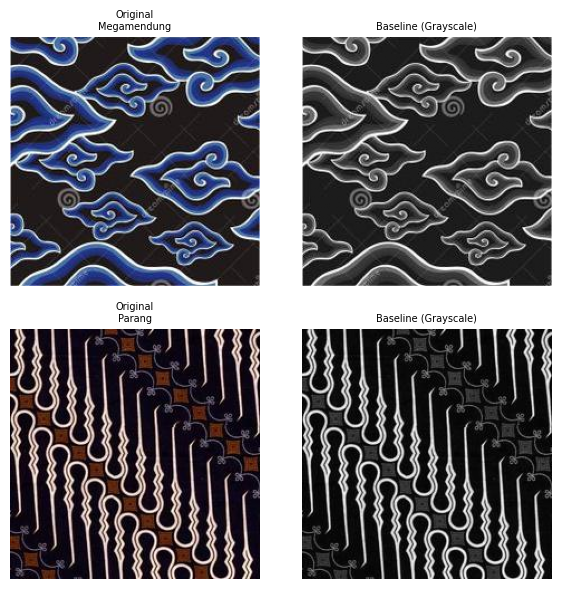

In [16]:
# Ambil 1 sampel pertama dari setiap kelas
sample_dict = {}

for i, label in enumerate(labels):
    if label not in sample_dict:
        sample_dict[label] = i

sample_idx = list(sample_dict.values())

# Tampilkan sampel
fig, axes = plt.subplots(len(sample_idx), 2, figsize=(6, len(sample_idx) * 3))

for row, i in enumerate(sample_idx):
    axes[row, 0].imshow(cv.cvtColor(data[i], cv.COLOR_BGR2RGB))
    axes[row, 0].set_title(f'Original\n{labels[i]}', fontsize=7)

    axes[row, 1].imshow(dataP0[i], cmap='gray')
    axes[row, 1].set_title('Baseline (Grayscale)', fontsize=7)

    for ax in axes[row]:
        ax.axis('off')

plt.tight_layout()
plt.show()

### Feature Extraction (GLCM)

Mendefinisikan fungsi `glcm()` untuk membangun matriks GLCM pada empat sudut (0°, 45°, 90°, 135°), serta tujuh fungsi untuk menghitung fitur tekstur: correlation, dissimilarity, homogenity, contrast, ASM, energy, dan entropy.

In [5]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Sudut harus salah satu dari: 0, 45, 90, 135")
    return graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())


Mendefinisikan `extract_glcm_features()` untuk mengekstrak 28 fitur (7 fitur x 4 sudut) dari seluruh citra dalam `dataP0`, kemudian menjalankannya untuk menghasilkan `features_p0`.

In [6]:
def extract_glcm_features(dataset):
    """Ekstrak semua fitur GLCM dari dataset"""
    Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
    dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
    homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
    entropy0, entropy45, entropy90, entropy135 = [], [], [], []
    ASM0, ASM45, ASM90, ASM135 = [], [], [], []
    energy0, energy45, energy90, energy135 = [], [], [], []
    correlation0, correlation45, correlation90, correlation135 = [], [], [], []

    for img in dataset:
        D0 = glcm(img, 0)
        D45 = glcm(img, 45)
        D90 = glcm(img, 90)
        D135 = glcm(img, 135)

        Kontras0.append(contrast(D0));     Kontras45.append(contrast(D45))
        Kontras90.append(contrast(D90));   Kontras135.append(contrast(D135))
        dissimilarity0.append(dissimilarity(D0));   dissimilarity45.append(dissimilarity(D45))
        dissimilarity90.append(dissimilarity(D90)); dissimilarity135.append(dissimilarity(D135))
        homogenity0.append(homogenity(D0));   homogenity45.append(homogenity(D45))
        homogenity90.append(homogenity(D90)); homogenity135.append(homogenity(D135))
        entropy0.append(entropyGlcm(D0));   entropy45.append(entropyGlcm(D45))
        entropy90.append(entropyGlcm(D90)); entropy135.append(entropyGlcm(D135))
        ASM0.append(ASM(D0));   ASM45.append(ASM(D45))
        ASM90.append(ASM(D90)); ASM135.append(ASM(D135))
        energy0.append(energy(D0));   energy45.append(energy(D45))
        energy90.append(energy(D90)); energy135.append(energy(D135))
        correlation0.append(correlation(D0));   correlation45.append(correlation(D45))
        correlation90.append(correlation(D90)); correlation135.append(correlation(D135))

    return {
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
    }

print("Mengekstrak fitur GLCM (Baseline P0)...")
features_p0 = extract_glcm_features(dataP0)
print("Ekstraksi selesai.")


Mengekstrak fitur GLCM (Baseline P0)...
Ekstraksi selesai.


### Write Extraction Results to CSV

Menyimpan hasil ekstraksi fitur GLCM (`features_p0`) ke dalam file `hasil_ekstraksi_p0.csv`, lengkap dengan kolom nama file dan label kelas.

In [7]:
def save_to_csv(features, filename):
    df = pd.DataFrame({'Filename': file_name, 'Label': labels, **features})
    df.to_csv(filename, index=False)
    print(f"Tersimpan: {filename}")
    return df

df_p0 = save_to_csv(features_p0, 'hasil_ekstraksi_p0.csv')
df_p0.head()


Tersimpan: hasil_ekstraksi_p0.csv


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Dissimilarity0,Dissimilarity45,Dissimilarity90,Dissimilarity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,"Baru_0001,megamendung.jpg",Megamendung,939.799808,2335.657524,1994.470191,2391.601681,16.505445,26.686581,25.351758,26.920952,...,0.007536,0.006500,0.086607,0.080302,0.086808,0.080620,0.859908,0.647679,0.701868,0.639243
1,"Baru_0002,megamendung.jpg",Megamendung,952.208600,1421.418488,550.793562,1337.913592,17.485066,20.881779,12.261211,20.062680,...,0.000634,0.000425,0.022801,0.020550,0.025186,0.020607,0.864251,0.795321,0.921275,0.807346
2,"Baru_0003,megamendung.jpg",Megamendung,1170.552010,2379.585996,1837.760710,2798.321965,20.654789,30.604396,27.620816,33.680890,...,0.000114,0.000099,0.012211,0.010193,0.010679,0.009936,0.885410,0.766734,0.820118,0.725685
3,"Baru_00034,megamendung.jpg",Megamendung,1007.465247,1390.084960,461.671625,1439.964367,18.417561,20.874801,10.760750,21.371715,...,0.005908,0.004062,0.071745,0.064440,0.076867,0.063734,0.899211,0.859703,0.953702,0.854671
4,"Baru_00035,megamendung.jpg",Megamendung,180.692625,527.476402,355.599556,481.797181,6.349135,11.792314,9.799307,11.002715,...,0.000684,0.000563,0.028779,0.023113,0.026150,0.023725,0.951903,0.858056,0.904979,0.870357


### Feature Selection

Menyeleksi fitur dengan korelasi antar fitur di bawah 0.95 menggunakan `select_features()` untuk mengurangi redundansi, lalu menampilkan heatmap korelasi fitur terpilih (`X0`).

Fitur terpilih: 13 dari 28


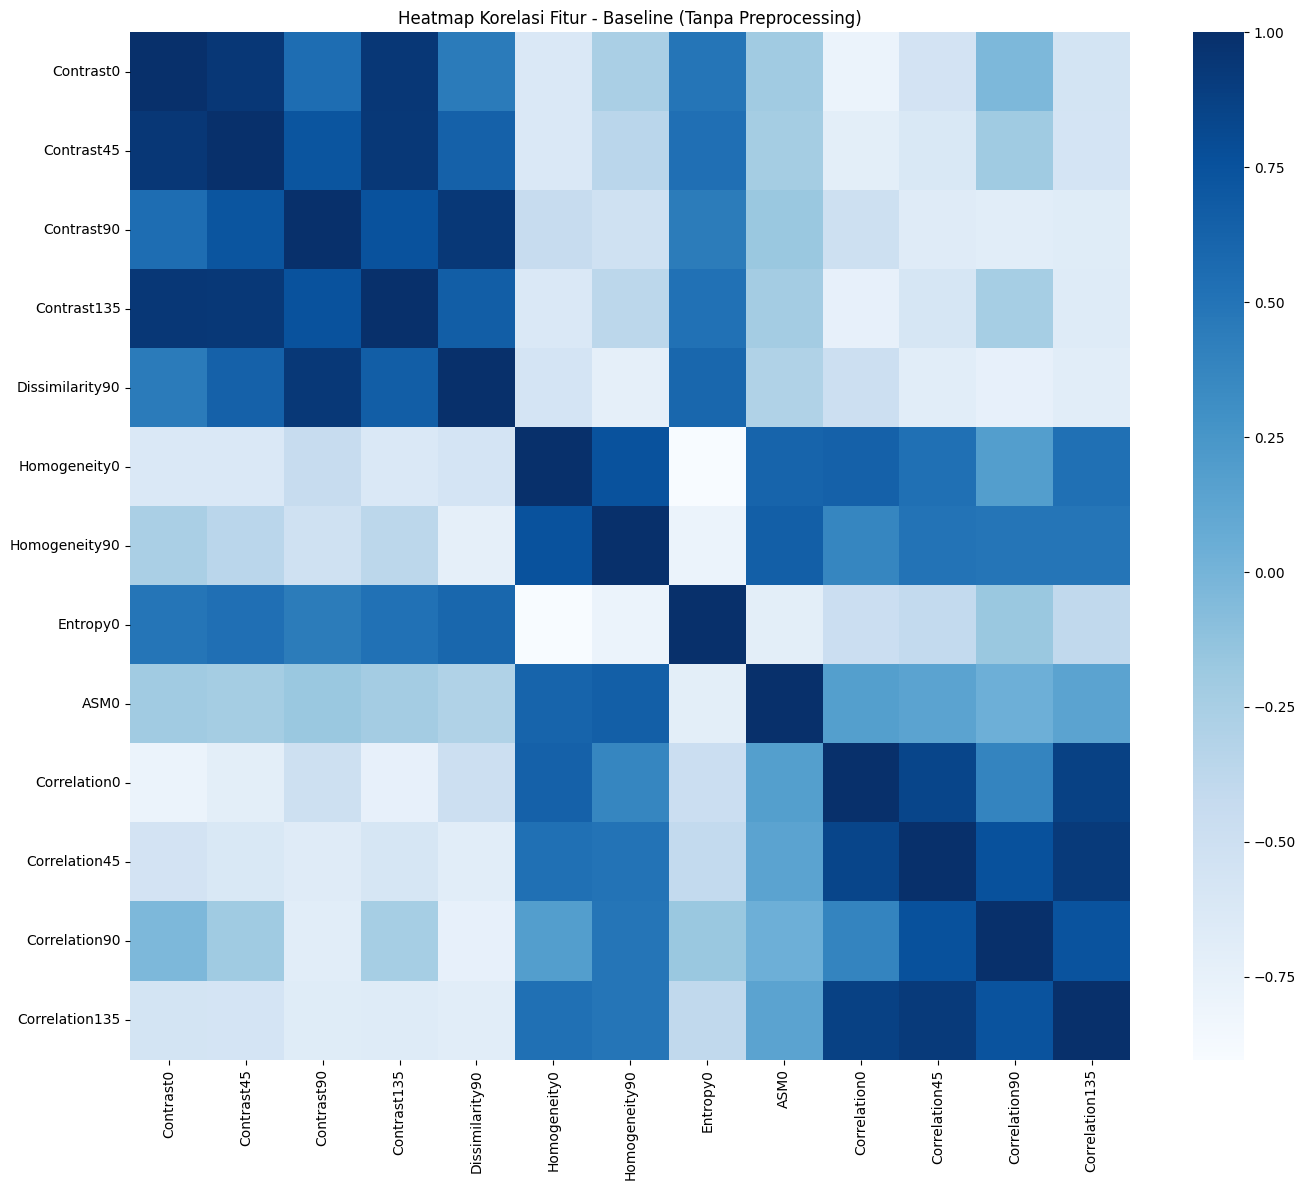

In [8]:
def select_features(df, threshold=0.95):
    """Seleksi fitur berdasarkan korelasi antar fitur"""
    correlation_matrix = df.drop(columns=['Label', 'Filename']).corr()
    columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)
    for i in range(correlation_matrix.shape[0]):
        for j in range(i+1, correlation_matrix.shape[0]):
            if correlation_matrix.iloc[i, j] >= threshold:
                if columns[j]:
                    columns[j] = False
    selected = df.drop(columns=['Label', 'Filename']).columns[columns]
    print(f"Fitur terpilih: {len(selected)} dari {len(correlation_matrix.columns)}")
    return df[selected], df['Label']

X0, y = select_features(df_p0)

plt.figure(figsize=(14, 12))
sns.heatmap(X0.corr(), annot=False, cmap='Blues')
plt.title('Heatmap Korelasi Fitur - Baseline (Tanpa Preprocessing)')
plt.tight_layout()
plt.show()


## Splitting Data

Membagi data fitur (`X0`) dan label (`y`) menjadi 80% data latih dan 20% data uji menggunakan `random_state=42` agar hasilnya dapat direproduksi dan konsisten dengan pembagian pada Percobaan 1, 2, dan 3.

In [9]:
X0_train, X0_test, y0_train, y0_test = train_test_split(X0, y, test_size=0.2, random_state=42)
print("Percobaan 0 (Baseline) - Train:", X0_train.shape, "| Test:", X0_test.shape)


Percobaan 0 (Baseline) - Train: (160, 13) | Test: (40, 13)


## Feature Normalization

Menerapkan standardisasi Z-score pada data latih dan data uji menggunakan mean dan standar deviasi dari data latih, agar skala fitur seragam sebelum masuk ke model SVM dan KNN yang sensitif terhadap skala.

In [10]:
def normalize(X_train, X_test):
    mean = X_train.mean()
    std = X_train.std()
    return (X_train - mean) / std, (X_test - mean) / std

X0_train, X0_test = normalize(X0_train, X0_test)
print("Normalisasi Percobaan 0 (Baseline) selesai.")


Normalisasi Percobaan 0 (Baseline) selesai.


## Modeling

Mendefinisikan fungsi bantu untuk evaluasi (`generateClassificationReport`, `plot_confusion_matrix`) serta inisialisasi tiga model klasifikasi: SVM kernel RBF, KNN dengan 5 tetangga, dan Random Forest dengan 100 pohon.

In [11]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

svm_model = SVC(kernel='rbf', random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=5)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)


### Percobaan 0 (Baseline, Tanpa Preprocessing) - SVM

===== PERCOBAAN 0 (Baseline) - SVM =====

--- Training Set ---
              precision    recall  f1-score   support

 Megamendung       0.92      0.97      0.94        79
      Parang       0.97      0.91      0.94        81

    accuracy                           0.94       160
   macro avg       0.95      0.94      0.94       160
weighted avg       0.95      0.94      0.94       160

Accuracy: 0.94375

--- Testing Set ---
              precision    recall  f1-score   support

 Megamendung       0.80      0.95      0.87        21
      Parang       0.93      0.74      0.82        19

    accuracy                           0.85        40
   macro avg       0.87      0.84      0.85        40
weighted avg       0.86      0.85      0.85        40

Accuracy: 0.85


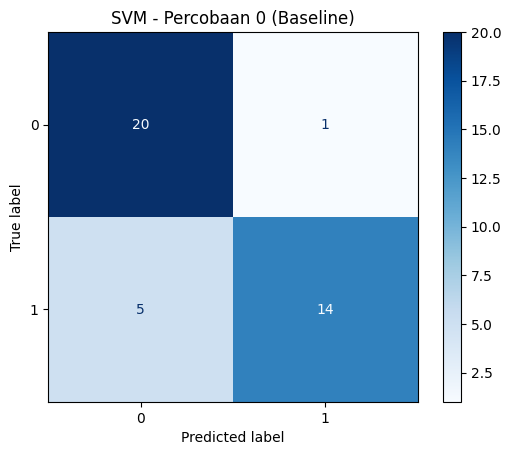

In [12]:
print("===== PERCOBAAN 0 (Baseline) - SVM =====")
svm_model.fit(X0_train, y0_train)
print("\n--- Training Set ---")
generateClassificationReport(y0_train, svm_model.predict(X0_train))
print("\n--- Testing Set ---")
generateClassificationReport(y0_test, svm_model.predict(X0_test))
plot_confusion_matrix(y0_test, svm_model.predict(X0_test), "SVM - Percobaan 0 (Baseline)")


SVM menghasilkan akurasi 85,00%, paling rendah di antara ketiga model pada baseline ini. SVM dengan kernel RBF mencari hyperplane optimal berdasarkan jarak antar titik di ruang fitur, sehingga lebih terdampak oleh variasi kontras dan pencahayaan citra mentah yang belum diekualisasi.

### Percobaan 0 (Baseline, Tanpa Preprocessing) - KNN

===== PERCOBAAN 0 (Baseline) - KNN =====

--- Training Set ---
              precision    recall  f1-score   support

 Megamendung       0.90      0.95      0.93        79
      Parang       0.95      0.90      0.92        81

    accuracy                           0.93       160
   macro avg       0.93      0.93      0.92       160
weighted avg       0.93      0.93      0.92       160

Accuracy: 0.925

--- Testing Set ---
              precision    recall  f1-score   support

 Megamendung       0.83      0.95      0.89        21
      Parang       0.94      0.79      0.86        19

    accuracy                           0.88        40
   macro avg       0.89      0.87      0.87        40
weighted avg       0.88      0.88      0.87        40

Accuracy: 0.875


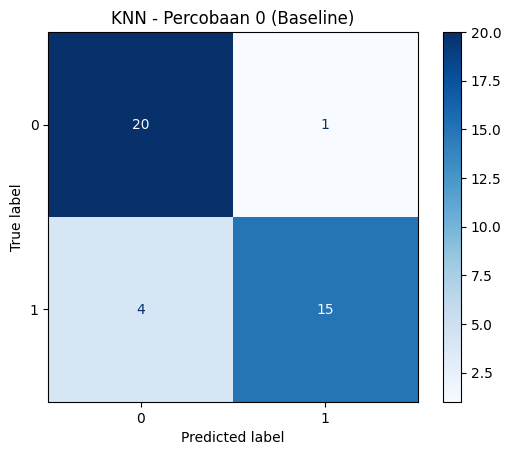

In [13]:
print("===== PERCOBAAN 0 (Baseline) - KNN =====")
knn_model.fit(X0_train, y0_train)
print("\n--- Training Set ---")
generateClassificationReport(y0_train, knn_model.predict(X0_train))
print("\n--- Testing Set ---")
generateClassificationReport(y0_test, knn_model.predict(X0_test))
plot_confusion_matrix(y0_test, knn_model.predict(X0_test), "KNN - Percobaan 0 (Baseline)")


KNN menghasilkan akurasi 87,50%, berada di tengah-tengah. Karena fitur sudah distandardisasi, sensitivitas KNN terhadap skala fitur sudah teratasi, namun model ini tetap rentan terhadap noise lokal pada citra yang belum diekualisasi sehingga belum mencapai performa maksimal.

### Percobaan 0 (Baseline, Tanpa Preprocessing) - Random Forest

===== PERCOBAAN 0 (Baseline) - Random Forest =====

--- Training Set ---
              precision    recall  f1-score   support

 Megamendung       1.00      1.00      1.00        79
      Parang       1.00      1.00      1.00        81

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160

Accuracy: 1.0

--- Testing Set ---
              precision    recall  f1-score   support

 Megamendung       0.87      0.95      0.91        21
      Parang       0.94      0.84      0.89        19

    accuracy                           0.90        40
   macro avg       0.91      0.90      0.90        40
weighted avg       0.90      0.90      0.90        40

Accuracy: 0.9


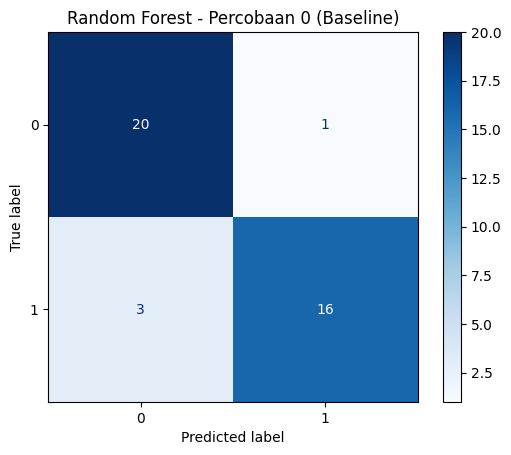

In [14]:
print("===== PERCOBAAN 0 (Baseline) - Random Forest =====\n")
rf_model.fit(X0_train, y0_train)
print("--- Training Set ---")
generateClassificationReport(y0_train, rf_model.predict(X0_train))
print("\n--- Testing Set ---")
generateClassificationReport(y0_test, rf_model.predict(X0_test))
plot_confusion_matrix(y0_test, rf_model.predict(X0_test), "Random Forest - Percobaan 0 (Baseline)")


Random Forest menghasilkan akurasi 90,00%, tertinggi di antara ketiga model. RF membangun keputusan berdasarkan threshold pada fitur individual melalui banyak pohon, sehingga lebih toleran terhadap variasi skala dan distribusi data yang belum melalui preprocessing dibandingkan model berbasis jarak seperti SVM dan KNN.

## Evaluation - Rekapitulasi Akurasi Baseline

Mengumpulkan akurasi testing dari SVM, KNN, dan Random Forest pada Percobaan 0 ke dalam satu tabel `df_results_p0` sebagai acuan pembanding terhadap Percobaan 1, 2, dan 3.

In [15]:
results_p0 = {
    'Percobaan': ['Percobaan 0 (Baseline)'],
    'Preprocessing': ['Tanpa Preprocessing (Grayscale saja)'],
    'Akurasi SVM': [accuracy_score(y0_test, SVC(kernel='rbf', random_state=42).fit(X0_train, y0_train).predict(X0_test))],
    'Akurasi KNN': [accuracy_score(y0_test, KNeighborsClassifier(n_neighbors=5).fit(X0_train, y0_train).predict(X0_test))],
    'Akurasi RF': [accuracy_score(y0_test, RandomForestClassifier(n_estimators=100, random_state=42).fit(X0_train, y0_train).predict(X0_test))],
}

df_results_p0 = pd.DataFrame(results_p0)
df_results_p0['Akurasi SVM'] = df_results_p0['Akurasi SVM'].apply(lambda x: f"{x*100:.2f}%")
df_results_p0['Akurasi KNN'] = df_results_p0['Akurasi KNN'].apply(lambda x: f"{x*100:.2f}%")
df_results_p0['Akurasi RF']  = df_results_p0['Akurasi RF'].apply(lambda x: f"{x*100:.2f}%")
print(df_results_p0.to_string(index=False))


             Percobaan                        Preprocessing Akurasi SVM Akurasi KNN Akurasi RF
Percobaan 0 (Baseline) Tanpa Preprocessing (Grayscale saja)      85.00%      87.50%     90.00%


### Kesimpulan 

Berdasarkan hasil Percobaan 0 (Baseline) yang hanya menggunakan proses grayscale tanpa preprocessing tambahan, diperoleh akurasi sebesar 85,00% pada SVM, 87,50% pada KNN, dan 90,00% pada Random Forest. Hasil ini menunjukkan bahwa citra batik yang telah dikonversi ke grayscale masih mampu memberikan informasi yang cukup untuk proses klasifikasi, dengan Random Forest menghasilkan performa terbaik dibandingkan dua algoritma lainnya. Oleh karena itu, hasil baseline ini dapat dijadikan sebagai acuan awal untuk mengevaluasi efektivitas metode preprocessing yang akan diterapkan pada percobaan selanjutnya dalam meningkatkan akurasi klasifikasi motif batik.

**Catatan:** Hasil `df_results_p0` di atas dapat digabungkan dengan tabel rekap akurasi dari notebook utama (Percobaan 1, 2, 3) untuk melihat perbandingan menyeluruh antara baseline tanpa preprocessing dan ketiga skenario preprocessing manual.